In [1]:
import matplotlib.pyplot as plt
import cantera as ct

In [2]:
p = 1 * ct.one_atm  # pressure
T_in = 373.0  # inlet temperature

# Mass flow rate of the reactant mixture from each side (kg/m^2/s)
mdot_reactants = 5

# CH4 + 2(O2 + 3.76 N2 + 0.036 Ar) -> CO2 + 2 H2O + 7.52 N2 + 0.072 Ar
# Mole ratios: CH4:1, O2:2, N2:7.52, AR:0.072
comp = 'CH4:1, O2:2, N2:7.52, AR:0.072'

width = 0.1  # m - simulation domain width
loglevel = 1  

# Set up the problem
gas = ct.Solution('gri30.yaml')

# set state to that of the unburned gas at the burner
gas.TPX = T_in, p, comp


In [3]:
# Create the flame simulation object
sim = ct.CounterflowPremixedFlame(gas=gas, width=width)

# Set grid refinement parameters
sim.set_refine_criteria(ratio=3, slope=0.1, curve=0.2, prune=0.02)

# Set the boundary flow rates
sim.reactants.mdot = mdot_reactants
sim.products.mdot = mdot_reactants # Set products stream flow rate equal to reactants

# Set an initial guess for the solution.
sim.set_initial_guess()
sim.show()



>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> reactants <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    Mass Flux:            5 kg/m^2/s 
    Temperature:        373 K 
    Mass Fractions: 
                      O2       0.218 
                     CH4     0.05465 
                      N2      0.7176 
                      AR    0.009798 



>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> flame <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    Pressure:   1.013e+05 Pa

-------------------------------------------------------------------------------
          z    velocity  spread_rate           T      lambda      eField 
-------------------------------------------------------------------------------
          0       5.521           0         373  -8.101e+04           0 
       0.03      -6.241       235.2         373  -8.101e+04           0 
       0.05      -14.08       392.1        1315  -8.101e+04           0 
       0.07      -21.92       235.2        2256  -8.101e+04           0 
        0.1      -33.69           0        

In [4]:
# auto=True attempts to solve by starting with a simpler problem and gradually increasing complexity.
sim.solve(loglevel, auto=True)

# sim.save(csv_path, basis="mole", overwrite=True) # Save solution to CSV file 

sim.show_stats()
sim.show() # Show final solution profile summary


************ Solving on 5 point grid with energy equation enabled ************

..............................................................................

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 2.136e-05  log(ss)= 5.938     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 1.52e-05   log(ss)= 6.586     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 2.165e-05  log(ss)= 5.957     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.0005548  log(ss)= 4.61      

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.02133    log(ss)= 2.045     

Attempt Newton solution 

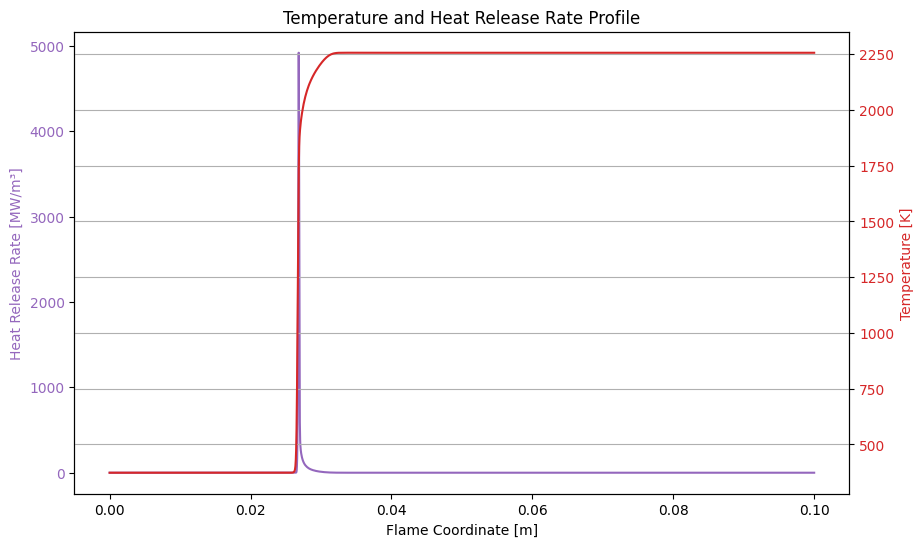

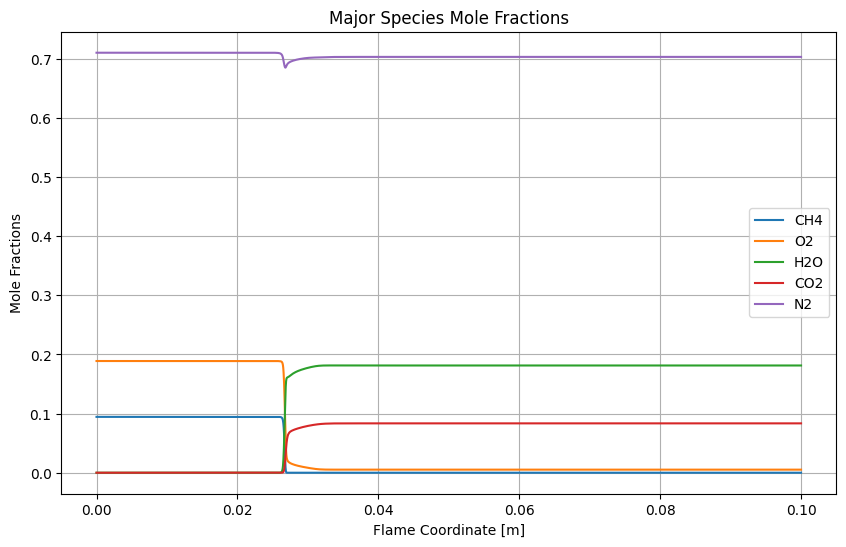

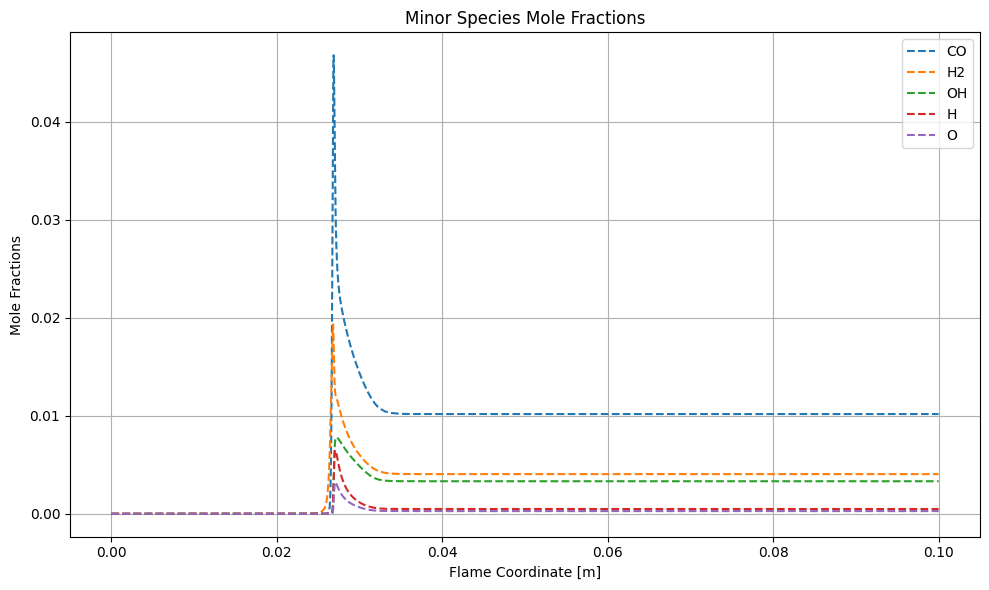

Simulation complete.


In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(sim.grid, sim.heat_release_rate / 1e6, color='C4')
ax1.set_ylabel('Heat Release Rate [MW/m³]', color='C4')
ax1.tick_params(axis='y', labelcolor='C4')
ax1.set_xlabel('Flame Coordinate [m]')

ax2 = ax1.twinx() # Create a second y-axis sharing the same x-axis
ax2.plot(sim.grid, sim.T, color='C3')
ax2.set_ylabel('Temperature [K]', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

plt.title('Temperature and Heat Release Rate Profile')
plt.grid(True)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
# Define major species for methane-air combustion
major = ('CH4', 'O2', 'H2O', 'CO2', 'N2')
states = sim.to_array() 
ax.plot(states.grid, states(*major).X, label=major)
ax.set(xlabel='Flame Coordinate [m]', ylabel='Mole Fractions')
ax.set_title('Major Species Mole Fractions')
ax.legend()
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
# Define some key minor species/intermediates for methane-air combustion
minor = ('CO', 'H2', 'OH', 'H', 'O')
ax.plot(states.grid, states(*minor).X, label=minor, linestyle='--')
ax.set(xlabel='Flame Coordinate [m]', ylabel='Mole Fractions')
ax.set_title('Minor Species Mole Fractions')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Simulation complete.")